In [1]:
import pandas as pd

# 1) Extraccion de datos

In [2]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

datos = pd.read_json(url)

datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [3]:
datos_norm_customer = pd.json_normalize(datos["customer"])
datos_norm_phone = pd.json_normalize(datos["phone"])
datos_norm_internet = pd.json_normalize(datos["internet"])
datos_norm_account = pd.json_normalize(datos["account"])

In [4]:
datos_base = datos.drop(columns=["customer", "phone", "internet", "account"])

datos_final = pd.concat(
    [datos_base, datos_norm_customer, datos_norm_phone, datos_norm_internet, datos_norm_account],
    axis=1
)

datos_final.head()


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#2) Transformacion de datos

In [5]:
datos_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [6]:
datos_final.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


In [7]:
pd.set_option('display.max_columns', None)
datos_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [8]:
datos_final.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [9]:
datos_final["customerID"].duplicated().sum()

np.int64(0)

In [10]:
datos_final["Churn"].duplicated().sum()

np.int64(7264)

In [11]:
datos_final.nunique()

,0
customerID,7267
Churn,3
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3


In [12]:
datos_final["Churn"].unique()

array(['No', 'Yes', ''], dtype=object)

In [13]:
datos_final["Churn"].isnull().sum()

np.int64(0)

In [14]:
datos_final["PaymentMethod"].unique()

array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

In [15]:
datos_final["Charges.Total"] = pd.to_numeric(datos_final["Charges.Total"], errors="coerce")

In [16]:
datos_final["Charges.Total"].isnull().sum()

np.int64(11)

In [17]:
datos_final[datos_final["Charges.Total"].isnull()]

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN


In [18]:
datos_final["Cuentas_Diarias"] = (datos_final["Charges.Monthly"] / 30).round(2)
datos_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [19]:
datos_final["MultipleLines"].unique()

array(['No', 'Yes', 'No phone service'], dtype=object)

In [20]:
datos_final["OnlineSecurity"].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [21]:
datos_final["OnlineBackup"].unique()

array(['Yes', 'No', 'No internet service'], dtype=object)

In [22]:
datos_final["DeviceProtection"].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [23]:
columnas = [ "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

for col in columnas:
    datos_final[col] = (datos_final[col].astype(str).str.strip().str.lower())

for col in columnas:
    datos_final[col] = datos_final[col].map({"yes": 1, "no": 0})


In [24]:
datos_final["Churn"] = datos_final["Churn"].astype(str).str.strip().str.lower()

In [25]:
datos_final['Churn'] = datos_final['Churn'].replace("", pd.NA)
datos_final.dropna(subset=['Churn'], inplace=True)

datos_final['Churn'] = datos_final['Churn'].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0}).astype(int)

In [26]:
datos_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,No,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [37]:
datos_final.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2283.300441,2.158675
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.771362,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,401.450000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3794.737500,2.990000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [28]:
datos_final["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [29]:
datos_final["Churn"].value_counts(normalize = True)*100

,proportion
Churn,
0,73.463013
1,26.536987


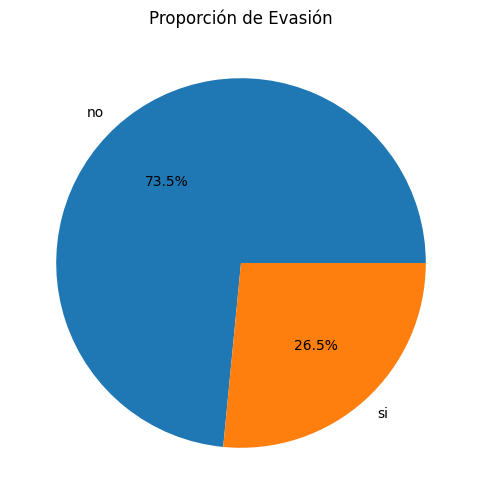

In [31]:
conteo = datos_final["Churn"].value_counts().sort_index()

plt.figure(figsize=(6,6))
plt.pie(
    conteo,
    labels=["no", "si"],
    autopct="%1.1f%%"
)
plt.title("Proporción de Evasión")
plt.ylabel("")
plt.show()

###Recuento de evasión por variables categóricas

In [41]:
datos_final.groupby("gender")["Churn"].mean().round(3) * 100

,Churn
gender,
Female,26.9
Male,26.2


In [40]:
datos_final.groupby("Contract")["Churn"].mean().round(3) * 100

,Churn
Contract,
Month-to-month,42.7
One year,11.3
Two year,2.8


In [39]:
datos_final.groupby("PaymentMethod")["Churn"].mean().round(3) * 100

,Churn
PaymentMethod,
Bank transfer (automatic),16.7
Credit card (automatic),15.2
Electronic check,45.3
Mailed check,19.1


In [42]:
datos_final.groupby("Partner")["Churn"].mean().round(3) * 100
# 33% no -  19.7% si

,Churn
Partner,
0,33.0
1,19.7


##Conteo de evasión por variables numéricas

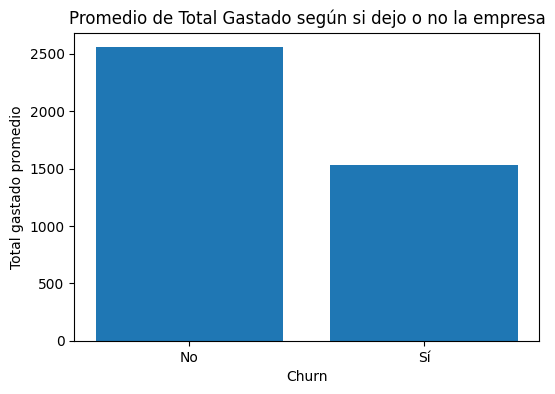

In [60]:
total_promedio = datos_final.groupby("Churn")["Charges.Total"].mean().round(2)
plt.figure(figsize=(6,4))

plt.bar(total_promedio.index, total_promedio.values)

plt.xticks([0,1], ["No", "Sí"])  # Cambiamos etiquetas
plt.title("Promedio de Total Gastado según si dejo o no la empresa")
plt.xlabel("Churn")
plt.ylabel("Total gastado promedio")

plt.show()

<Figure size 600x400 with 0 Axes>

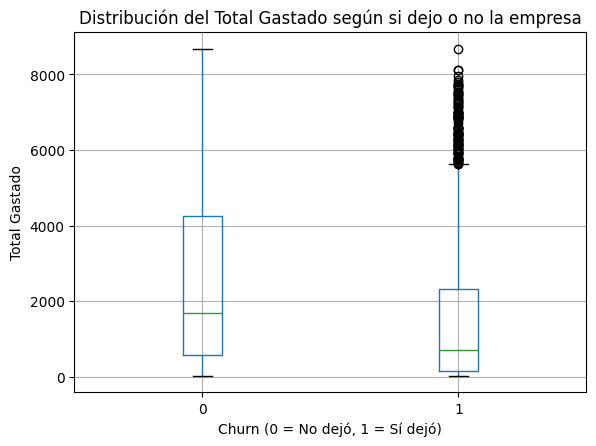

In [49]:
plt.figure(figsize=(6,4))
datos_final.boxplot(column="Charges.Total", by="Churn")

plt.title("Distribución del Total Gastado según si dejo o no la empresa")
plt.suptitle("")
plt.xlabel("Churn (0 = No dejó, 1 = Sí dejó)")
plt.ylabel("Total Gastado")
plt.show()

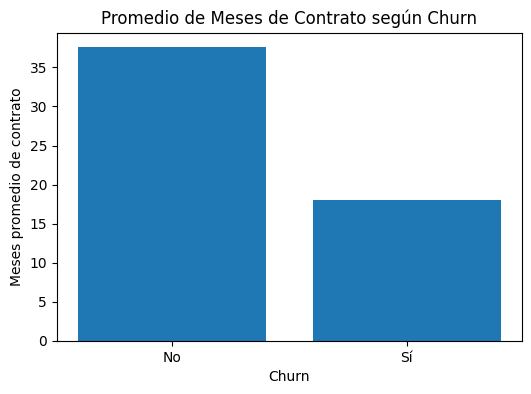

In [58]:
tenure_promedio = datos_final.groupby("Churn")["tenure"].mean().round(2)

plt.figure(figsize=(6,4))

plt.bar(tenure_promedio.index, tenure_promedio.values)

plt.xticks([0,1], ["No", "Sí"])  # Cambiamos las etiquetas del eje X
plt.title("Promedio de Meses de Contrato según Churn")
plt.xlabel("Churn")
plt.ylabel("Meses promedio de contrato")

plt.show()

<Figure size 600x400 with 0 Axes>

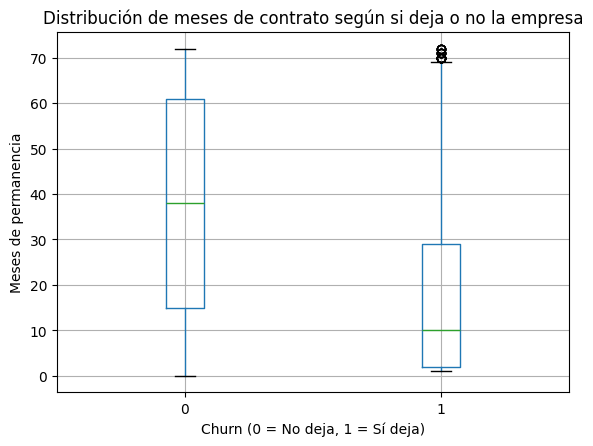

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

datos_final.boxplot(column="tenure", by="Churn")

plt.title("Distribución de meses de contrato según si deja o no la empresa")
plt.suptitle("")
plt.xlabel("Churn (0 = No deja, 1 = Sí deja)")
plt.ylabel("Meses de permanencia")

plt.show()

#Informe final

##Introducción

El objetivo de este análisis es comprender los factores que influyen en la evasión de clientes en Telecom X.
En este proyecto se realizó un proceso completo de análisis de datos utilizando Python, Pandas y Matplotlib. A partir de los datos disponibles sobre los clientes, se buscó identificar patrones y variables que puedan estar asociadas con una mayor probabilidad de cancelación del servicio.

##Limpieza y Tratamiento de Datos

Los datos fueron obtenidos desde una API en formato JSON y cargados en un DataFrame utilizando la biblioteca Pandas. Debido a que el archivo contenía estructuras anidadas, se utilizó **json_normalize()** para convertir esas estructuras en columnas independientes y así facilitar su análisis.
Posteriormente se realizó una validación de los datos para detectar valores nulos, duplicados y errores de formato. Algunas columnas fueron transformadas para mejorar su uso analítico, como la conversión de variables categóricas a valores binarios y la transformación de la columna **Charges.Total** a tipo numérico. Además, se creó una nueva variable llamada **Cuentas_Diarias**, calculada a partir del cargo mensual.

##Análisis exploratorio de datos

El análisis mostró que aproximadamente **26.5%** de los clientes cancelaron el servicio, mientras que el **73.5%** permanecen en la empresa.

Al analizar variables categóricas se observó que el tipo de contrato tiene una fuerte relación con si dejaron el serivicio. Los clientes con contratos mensuales presentan una tasa de cancelación mucho mayor que aquellos con contratos de uno o dos años. También se identificó que el método de pago **Electronic Check** está asociado con mayores niveles de evasión.
Por otro lado, el análisis de variables numéricas mostró que los clientes que cancelan el servicio tienen, en promedio, menos meses de permanencia y menor gasto total acumulado que los clientes que continúan en la empresa. Esto sugiere que los clientes nuevos tienen mayor probabilidad de abandonar el servicio.

##Conclusiones

A partir del análisis realizado se identificaron varios factores asociados con la evasión de clientes. Los contratos mensuales presentan las tasas más altas de cancelación, mientras que los contratos de mayor duración muestran una mayor retención. Además, los clientes con menor tiempo en la empresa tienden a cancelar con mayor frecuencia.
Estos resultados indican que el compromiso del cliente con el servicio, reflejado en la duración del contrato y el tiempo de permanencia, es un factor clave en la retención.

##Recomendaciones

Con base en los resultados obtenidos, se recomienda incentivar contratos de mayor duración mediante descuentos o beneficios para los clientes. También sería útil implementar estrategias de retención durante los primeros meses de servicio, ya que es en ese período donde se observa mayor riesgo de cancelación. Finalmente, promover métodos de pago automáticos podría contribuir a reducir la tasa de evasión.